# PROCESS large tokamak — evaluation design point

fusdb against the PROCESS run in `reference/eval_point/`
(`ioptimz = -2`, i.e. a pure forward evaluation with no optimiser).

Two views: the signed deviation per quantity against the 10% acceptance band,
and the supplied profiles against PROCESS's own.

In [1]:
# Validated categorical order (dataviz palette): slot 1 blue, slot 2 orange.
# Two series only, assigned in fixed order and never cycled.
FUSDB, PROCESS = '#2a78d6', '#eb6834'
import matplotlib.pyplot as plt, numpy as np, sys
sys.path.insert(0, '.')
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':0.25, 'grid.linewidth':0.6,
                     'axes.labelcolor':'#52514e', 'text.color':'#0b0b0b',
                     'xtick.color':'#52514e', 'ytick.color':'#52514e', 'font.size':9})

from _process_compare import compare, TOLERANCE
from _process_fixture import EVAL_POINT
fields, result = compare(EVAL_POINT)
print('regime:', result['regime'], '| certified:', result['success'],
      '| failed relations:', len(result['failed_relations']))

/home/alessmor/Scrivania/fusdb/src/fusdb/relations/confinement/scalings/ITER.py:900: RuntimeWarning: invalid value encountered in scalar power
  * p_plasma_loss_mw ** (-0.69e0)


regime: h_mode | certified: True | failed relations: 0


## Deviation per quantity

Sorted by magnitude. The shaded band is the +/-10% acceptance criterion;
every bar sits inside it. Direct labels rather than a value on every tick.

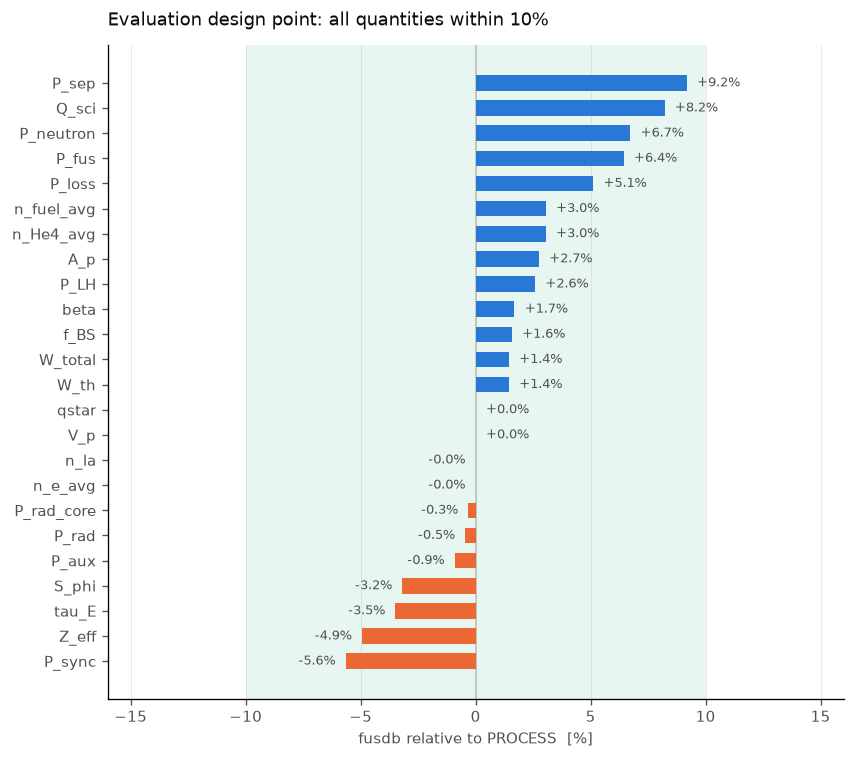

In [2]:
names = sorted(fields, key=lambda k: fields[k]['rel_error'])
err = np.array([fields[k]['rel_error']*100 for k in names])
fig, ax = plt.subplots(figsize=(7.2, 6.4))
ax.axvspan(-10, 10, color='#1baf7a', alpha=0.10, lw=0, zorder=0)
ax.axvline(0, color='#c3c2b7', lw=1, zorder=1)
# One series: colour carries sign, not identity, so no legend box is needed.
colors = [FUSDB if e >= 0 else PROCESS for e in err]
ax.barh(names, err, color=colors, height=0.62, zorder=2)
for y, e in enumerate(err):
    ax.text(e + (0.45 if e >= 0 else -0.45), y, f'{e:+.1f}%', va='center',
            ha='left' if e >= 0 else 'right', fontsize=8, color='#52514e')
ax.set_xlabel('fusdb relative to PROCESS  [%]')
ax.set_xlim(-16, 16)
ax.set_title('Evaluation design point: all quantities within 10%', loc='left', pad=12)
ax.grid(axis='y', visible=False)
fig.tight_layout()

## Profiles

fusdb is handed PROCESS's own analytic pedestal profile
(`i_plasma_pedestal = 1`), rebuilt by `_fixture.py` on fusdb's rho grid,
because fusdb's parabolic-via-peaking family cannot represent a pedestal.

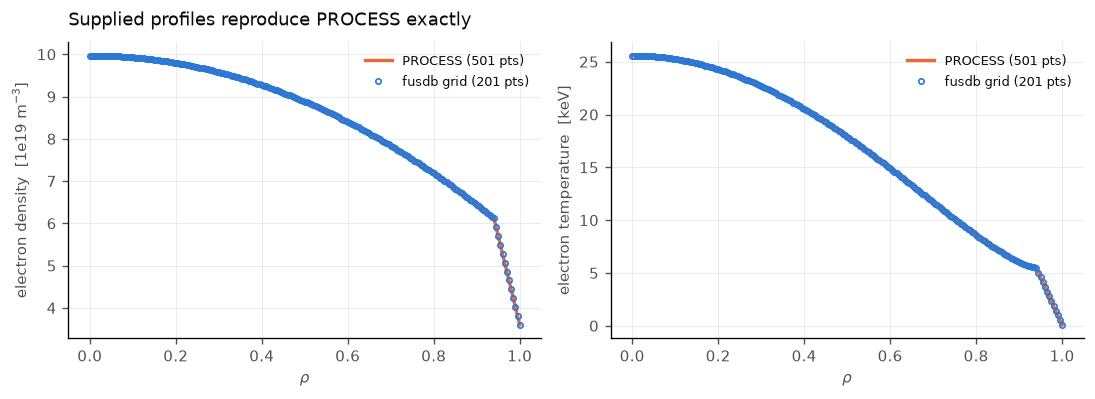

In [3]:
from _process_fixture import build_config, n_profile, t_profile, PROFILE_SIZE
from _process_mfile import read_mfile
d = read_mfile(EVAL_POINT); g = lambda k: d[k][1]
rho_f = np.linspace(0, 1, PROFILE_SIZE)
rho_p = np.linspace(0, 1, 501)
args_n = ('nd_plasma_electron_on_axis','nd_plasma_pedestal_electron',
          'nd_plasma_separatrix_electron','radius_plasma_pedestal_density_norm','alphan')
args_t = ('temp_plasma_electron_on_axis_kev','temp_plasma_pedestal_kev',
          'temp_plasma_separatrix_kev','radius_plasma_pedestal_temp_norm','alphat','tbeta')
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.4))
for ax, (fn, args, lab, scale) in zip(axes, [
        (n_profile, args_n, 'electron density  [1e19 m$^{-3}$]', 1e-19),
        (t_profile, args_t, 'electron temperature  [keV]', 1.0)]):
    ax.plot(rho_p, fn(rho_p, *[g(a) for a in args])*scale, color=PROCESS, lw=2, label='PROCESS (501 pts)')
    ax.plot(rho_f, fn(rho_f, *[g(a) for a in args])*scale, color=FUSDB, lw=0, marker='o',
            ms=3.2, mfc='none', label=f'fusdb grid ({PROFILE_SIZE} pts)')
    ax.set_xlabel(r'$\rho$'); ax.set_ylabel(lab); ax.legend(frameon=False, fontsize=8)
axes[0].set_title('Supplied profiles reproduce PROCESS exactly', loc='left', pad=10)
fig.tight_layout()

The fusdb grid is a subsample of the same analytic curve, so the two coincide by
construction. The grid size is not cosmetic: `P_aux` is a difference of two large
numbers and inherits the quadrature error, which is why `_fixture.py` uses 201
points rather than fusdb's default 46 (see the convergence table there).